In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("../data/processed/logistics_preprocessed.csv")

In [3]:
print(df.shape)

print(df.columns)

df.info()

df.head()

(249231, 21)
Index(['Route ID', 'Driver ID', 'Stop ID', 'Address ID', 'Week ID', 'Country',
       'Day of Week', 'IndexP', 'IndexA', 'Arrived Time', 'Earliest Time',
       'Latest Time', 'DistanceP', 'DistanceA', 'Depot', 'Delivery',
       'Route Deviation', 'DistanceP_Normalized', 'DistanceA_Normalized',
       'DistanceP_Standardized', 'DistanceA_Standardized'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 249231 entries, 0 to 249230
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Route ID                249231 non-null  int64  
 1   Driver ID               249231 non-null  int64  
 2   Stop ID                 249231 non-null  int64  
 3   Address ID              249231 non-null  int64  
 4   Week ID                 249231 non-null  int64  
 5   Country                 249231 non-null  int64  
 6   Day of Week             249231 non-null  str    
 7   IndexP              

,Route ID,Driver ID,Stop ID,Address ID,Week ID,Country,Day of Week,IndexP,IndexA,Arrived Time,...,Latest Time,DistanceP,DistanceA,Depot,Delivery,Route Deviation,DistanceP_Normalized,DistanceA_Normalized,DistanceP_Standardized,DistanceA_Standardized
0,0,0,0,0,0,1,Monday,0,0,42.275,...,360.0,0.000000,0.000000,1,0,0.000000,0.000000,0.000000,-0.367459,-0.360602
1,0,0,1,1,0,1,Tuesday,1,4,332.788,...,480.0,16.329053,16.329053,0,1,0.000000,0.029628,0.029628,0.818877,0.821290
2,0,0,2,2,0,1,Tuesday,2,5,332.956,...,540.0,0.373110,0.373110,0,1,0.000000,0.000677,0.000677,-0.340352,-0.333596
3,0,0,3,3,0,1,Monday,3,2,244.994,...,540.0,2.491915,0.000000,0,1,-2.491915,0.004521,0.000000,-0.186417,-0.360602
4,0,0,4,3,0,1,Monday,4,1,244.855,...,540.0,0.000000,13.944962,0,1,13.944962,0.000000,0.025303,-0.367459,0.648730


In [4]:
correlation = df[
    ["DistanceP",
     "DistanceA",
     "Arrived Time",
     "Earliest Time",
     "Latest Time"]
].corr()

print(correlation)

               DistanceP  DistanceA  Arrived Time  Earliest Time  Latest Time
DistanceP       1.000000   0.865370      0.004312       0.003674     0.004375
DistanceA       0.865370   1.000000      0.004296       0.003144     0.003856
Arrived Time    0.004312   0.004296      1.000000       0.938326     0.938318
Earliest Time   0.003674   0.003144      0.938326       1.000000     0.999984
Latest Time     0.004375   0.003856      0.938318       0.999984     1.000000


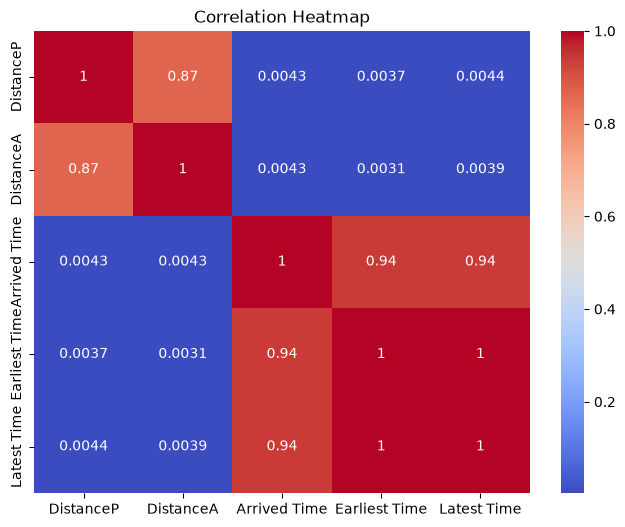

In [5]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

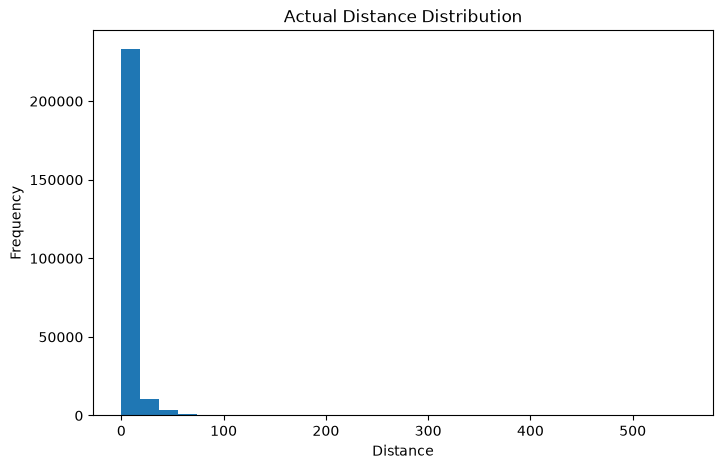

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    df["DistanceA"],
    bins=30
)

plt.title("Actual Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

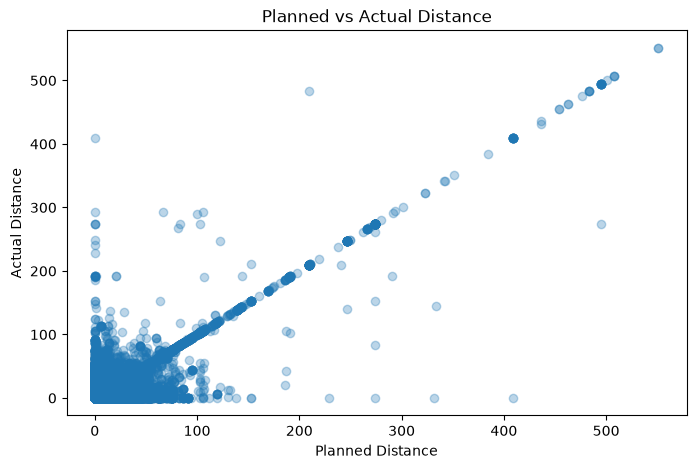

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["DistanceP"],
    df["DistanceA"],
    alpha=0.3
)

plt.xlabel("Planned Distance")
plt.ylabel("Actual Distance")

plt.title("Planned vs Actual Distance")

plt.show()

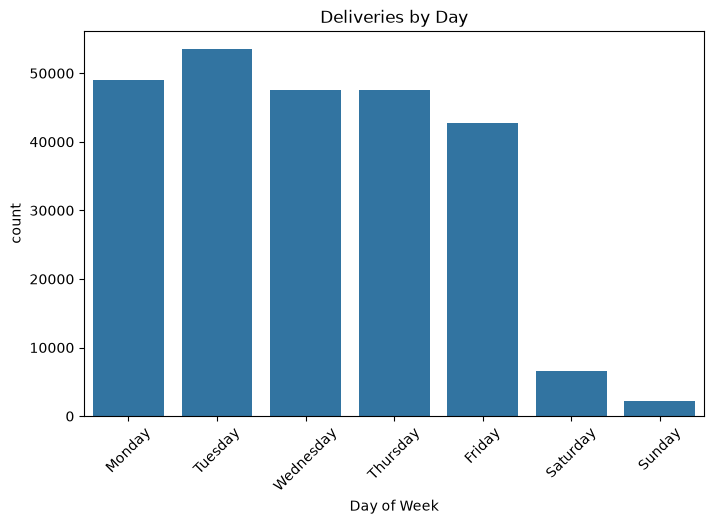

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Day of Week",
    data=df
)

plt.title("Deliveries by Day")

plt.xticks(rotation=45)

plt.show()